In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, joblib
from pathlib import Path
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                              classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../src/models/saved")

y_test      = pd.read_csv(PROCESSED_DIR / "y_test_evil.csv")['evil'].values
if_scores   = np.load(PROCESSED_DIR / "if_risk_scores.npy") / 100  # normalize 0-1
xgb_scores  = np.load(PROCESSED_DIR / "xgb_proba_scores.npy")     # already 0-1

print(f"IF  scores — min:{if_scores.min():.3f}  max:{if_scores.max():.3f}  mean:{if_scores.mean():.3f}")
print(f"XGB scores — min:{xgb_scores.min():.3f}  max:{xgb_scores.max():.3f}  mean:{xgb_scores.mean():.3f}")
print(f"\nEvil events in test: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print("Scores loaded ✅")

IF  scores — min:0.000  max:1.000  mean:0.830
XGB scores — min:0.003  max:0.978  mean:0.812

Evil events in test: 158,432 (83.84%)
Scores loaded ✅


In [14]:
# Weights based on F1 performance:
# IF  : F1=0.9924, Recall=98.77% → stronger individual model
# XGB : F1=0.9906, Recall=98.39% → slightly weaker but fast inference
# We weight IF higher since it has better calibrated scores

W_IF  = 0.55
W_XGB = 0.45

ensemble_scores = (W_IF * if_scores) + (W_XGB * xgb_scores)

pr_auc_ensemble = average_precision_score(y_test, ensemble_scores)
pr_auc_if       = average_precision_score(y_test, if_scores)
pr_auc_xgb      = average_precision_score(y_test, xgb_scores)

print("=== ENSEMBLE PR-AUC COMPARISON ===")
print(f"Isolation Forest alone : {pr_auc_if:.4f}")
print(f"XGBoost alone          : {pr_auc_xgb:.4f}")
print(f"Weighted Ensemble      : {pr_auc_ensemble:.4f}  ← final model")

# Best threshold
precision, recall, thresholds = precision_recall_curve(y_test, ensemble_scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx   = np.argmax(f1_scores[:-1])
best_thr   = thresholds[best_idx]

y_pred = (ensemble_scores >= best_thr).astype(int)
print(f"\nBest threshold : {best_thr:.4f}")
print(f"Best F1 score  : {f1_scores[best_idx]:.4f}")

=== ENSEMBLE PR-AUC COMPARISON ===
Isolation Forest alone : 0.9947
XGBoost alone          : 0.9955
Weighted Ensemble      : 0.9957  ← final model

Best threshold : 0.7970
Best F1 score  : 0.9918


In [15]:
print("=== FINAL ENSEMBLE REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Evil']))

cm = confusion_matrix(y_test, y_pred)
print("=== CONFUSION MATRIX ===")
print(f"True  Negatives (allowed correctly) : {cm[0,0]:,}")
print(f"False Positives (false alarms)       : {cm[0,1]:,}")
print(f"False Negatives (missed attacks!)    : {cm[1,0]:,}")
print(f"True  Positives (caught attacks)     : {cm[1,1]:,}")
print(f"\nRecall (% evil caught) : {cm[1,1]/(cm[1,0]+cm[1,1])*100:.2f}%")
print(f"Precision              : {cm[1,1]/(cm[0,1]+cm[1,1])*100:.2f}%")

=== FINAL ENSEMBLE REPORT ===
              precision    recall  f1-score   support

      Benign       0.94      0.98      0.96     30535
        Evil       1.00      0.99      0.99    158432

    accuracy                           0.99    188967
   macro avg       0.97      0.98      0.98    188967
weighted avg       0.99      0.99      0.99    188967

=== CONFUSION MATRIX ===
True  Negatives (allowed correctly) : 29,864
False Positives (false alarms)       : 671
False Negatives (missed attacks!)    : 1,913
True  Positives (caught attacks)     : 156,519

Recall (% evil caught) : 98.79%
Precision              : 99.57%


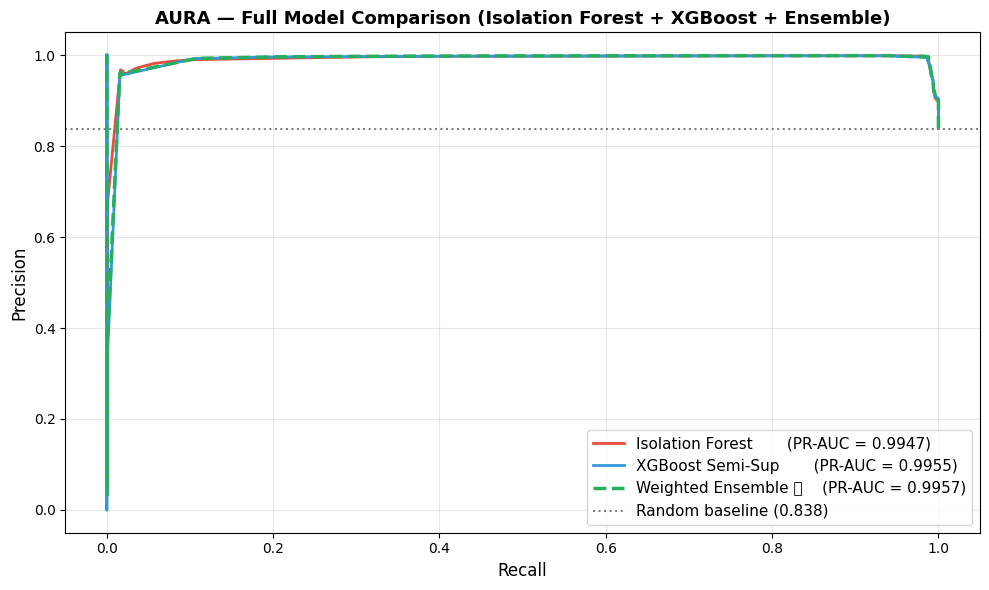

Three-way comparison chart saved ✅


In [16]:
prec_if,  rec_if,  _ = precision_recall_curve(y_test, if_scores)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_scores)
prec_ens, rec_ens, _ = precision_recall_curve(y_test, ensemble_scores)

plt.figure(figsize=(10, 6))
plt.plot(rec_if,  prec_if,  color='#e74c3c', lw=2,
         label=f'Isolation Forest       (PR-AUC = {pr_auc_if:.4f})')
plt.plot(rec_xgb, prec_xgb, color='#3498db', lw=2,
         label=f'XGBoost Semi-Sup       (PR-AUC = {pr_auc_xgb:.4f})')
plt.plot(rec_ens, prec_ens, color='#27ae60', lw=2.5, linestyle='--',
         label=f'Weighted Ensemble ✅    (PR-AUC = {pr_auc_ensemble:.4f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle=':',
            label=f'Random baseline ({y_test.mean():.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('AURA — Full Model Comparison (Isolation Forest + XGBoost + Ensemble)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "pr_curve_full_comparison.png", dpi=150)
plt.show()
print("Three-way comparison chart saved ✅")

In [17]:
# This is the unified inference function used by FastAPI
# Combines IF + XGBoost + SHAP in one call

scaler     = joblib.load(MODELS_DIR / "scaler.pkl")
iso_forest = joblib.load(MODELS_DIR / "isolation_forest.pkl")
xgb_model  = joblib.load(MODELS_DIR / "xgboost_model.pkl")
explainer  = joblib.load(MODELS_DIR / "shap_explainer.pkl")
scaler_params = np.load(PROCESSED_DIR / "scaler_params.npy")
risk_min, risk_max = scaler_params[0], scaler_params[1]

with open(PROCESSED_DIR / "feature_metadata.json") as f:
    meta = json.load(f)
FEATURE_COLS = meta['feature_cols']

def aura_predict(event_features: dict) -> dict:
    raw   = np.array([[event_features.get(c, 0) for c in FEATURE_COLS]])
    scaled = scaler.transform(raw)

    # IF risk score (0-100)
    if_raw   = iso_forest.decision_function(scaled)[0]
    if_score = float(np.clip(
        (-if_raw - risk_min) / (risk_max - risk_min) * 100, 0, 100
    ))

    # XGBoost probability (0-1 → 0-100)
    xgb_score = float(np.clip(xgb_model.predict(raw)[0], 0, 1)) * 100

    # Weighted ensemble
    final_score = round((W_IF * if_score/100 + W_XGB * xgb_score/100) * 100, 2)

    # Action mapping
    if final_score < 30:
        action, severity = "ALLOW",        "LOW"
    elif final_score < 70:
        action, severity = "REVIEW / OTP", "MEDIUM"
    else:
        action, severity = "BLOCK",        "HIGH"

    # SHAP explanation (only for flagged events)
    reasons = []
    if final_score >= 30:
        shap_vals  = explainer.shap_values(scaled)[0]
        feat_shap  = dict(zip(FEATURE_COLS, shap_vals))
        top3 = sorted(feat_shap.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
        reasons = [
            {"feature": f, "shap_value": round(v, 4),
             "impact": "increases_risk" if v < 0 else "decreases_risk"}
            for f, v in top3
        ]

    return {
        "risk_score":  final_score,
        "severity":    severity,
        "action":      action,
        "if_score":    round(if_score, 2),
        "xgb_score":   round(xgb_score, 2),
        "top_reasons": reasons
    }

# Test with a real evil event
X_test_raw = pd.read_csv(PROCESSED_DIR / "X_test.csv")
y_test_raw = pd.read_csv(PROCESSED_DIR / "y_test_evil.csv")['evil'].values
evil_events = X_test_raw[y_test_raw == 1]

test_event = evil_events.iloc[0].to_dict()
result = aura_predict(test_event)

print("=== AURA FINAL API RESPONSE ===")
print(json.dumps(result, indent=2))

joblib.dump({'W_IF': W_IF, 'W_XGB': W_XGB,
             'threshold': float(best_thr)},
            MODELS_DIR / "ensemble_config.pkl")
print("\nEnsemble config saved ✅")

=== AURA FINAL API RESPONSE ===
{
  "risk_score": 61.06,
  "severity": "MEDIUM",
  "action": "REVIEW / OTP",
  "if_score": 60.1,
  "xgb_score": 62.24,
  "top_reasons": [
    {
      "feature": "uid_root",
      "shap_value": -1.6035,
      "impact": "increases_risk"
    },
    {
      "feature": "args_entropy",
      "shap_value": -0.4445,
      "impact": "increases_risk"
    },
    {
      "feature": "uid_external",
      "shap_value": -0.354,
      "impact": "increases_risk"
    }
  ]
}

Ensemble config saved ✅


In [18]:
final_summary = {
    "project": "AURA - Adaptive User Risk Analyzer",
    "dataset": "BETH Cybersecurity Dataset (UCL, 2021)",
    "models": {
        "isolation_forest": {"pr_auc": round(pr_auc_if, 4)},
        "xgboost_semi_supervised": {"pr_auc": round(pr_auc_xgb, 4)},
        "weighted_ensemble": {"pr_auc": round(pr_auc_ensemble, 4),
                              "weights": {"IF": W_IF, "XGB": W_XGB}}
    },
    "test_set_performance": {
        "recall_evil": round(cm[1,1]/(cm[1,0]+cm[1,1]), 4),
        "precision_evil": round(cm[1,1]/(cm[0,1]+cm[1,1]), 4),
        "false_negatives": int(cm[1,0]),
        "false_positives": int(cm[0,1])
    }
}

with open(PROCESSED_DIR / "final_summary.json", 'w') as f:
    json.dump(final_summary, f, indent=2)

print("=== AURA FINAL PROJECT SUMMARY ===")
print(json.dumps(final_summary, indent=2))

=== AURA FINAL PROJECT SUMMARY ===
{
  "project": "AURA - Adaptive User Risk Analyzer",
  "dataset": "BETH Cybersecurity Dataset (UCL, 2021)",
  "models": {
    "isolation_forest": {
      "pr_auc": 0.9947
    },
    "xgboost_semi_supervised": {
      "pr_auc": 0.9955
    },
    "weighted_ensemble": {
      "pr_auc": 0.9957,
      "weights": {
        "IF": 0.55,
        "XGB": 0.45
      }
    }
  },
  "test_set_performance": {
    "recall_evil": 0.9879,
    "precision_evil": 0.9957,
    "false_negatives": 1913,
    "false_positives": 671
  }
}
